## いくつかvisibility dataの加工に関するテストをしておく

1. CASA `simobserve`のsignal visibilityを、`glint.context.UVContext` + `glint.forward.cube_to_visibilities`で再現できるか
2. baseline-dependent time averaging (maxuvwdistance) 後の代表uv点でモデルを評価する近似が、visibilityをどれだけ変えるか
3. line-free channelがGaussian noiseか、またMSの`WEIGHT`が誤差を正しく表すか
4. 異なる2観測の結合で`statwt`が必要か、元WEIGHT・手計算・`statwt`後を比較、`statwt`を使って良いか

In [1]:
from pathlib import Path
import os
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import stats

from casatasks import simobserve, exportfits, mstransform
from glint.context import build_uv_observation, flatten_selected
from glint.forward import cube_to_visibilities
from glint.interferometer import primary_beam
from glint.uv_processing import (
    channel_noise_correlation,
    concat_ms,
    get_msdata,
    noise_gaussianity_summary,
    plot_channel_noise_correlation,
    plot_noise_gaussianity,
    process_msdata,
    weight_sigma_column_summary,
)
from glint.lensing import make_grid_arcsec
from glint.plotstyle import set_my_plot_style
set_my_plot_style()

%matplotlib inline


## Mock data

中央7 channelだけに輝線を入れ、両端4 channelずつをline-freeとする。積分時間10 s、総観測時間1 h (Stage 3と同じ)。時間平均は現在採用している`maxuvwdistance=12 m`の前後も比較する。

In [2]:
WORK = Path('test_visibility_processing_work').resolve()
PROJECT = WORK / 'gaussian_test'
INPUT_FITS = WORK / 'gaussian_line_cube.fits'
CASA_MODEL_FITS = WORK / 'casa_skymodel.fits'

NX = NY = 128
NCHAN = 15
PIXEL_ARCSEC = 0.03
CENTER_FREQ_HZ = 270.0e9
CHANNEL_WIDTH_HZ = 50.0e6
INTEGRATION = '10s'
TOTAL_TIME = '3600s'
MAX_UV_DISTANCES_M = [3.0, 6.0, 12.0, 24.0, 48.0]
LINE_FREE = np.r_[0:4, NCHAN-4:NCHAN]
SEED = 20260820

CONFIG = Path('../data/configuration_files/alma.cycle7.5.cfg')
ANTENNA_CONFIG = CONFIG.resolve()

# 既存MSがあれば再利用
if WORK.exists() and not PROJECT.exists():
    shutil.rmtree(WORK)
WORK.mkdir(parents=True, exist_ok=True)
print('line-free channels:', LINE_FREE.tolist())

line-free channels: [0, 1, 2, 3, 11, 12, 13, 14]


## Make mock cube

空間方向は位相中心からずらした楕円Gaussian、スペクトル方向は中央のみ非ゼロのGaussianとする。

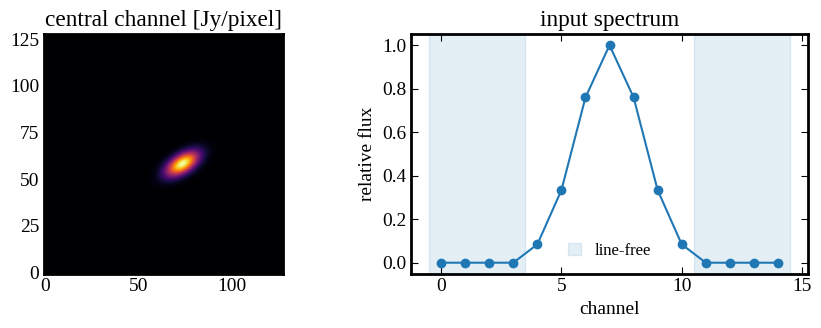

In [3]:
xx, yy = make_grid_arcsec(NX, NY, PIXEL_ARCSEC)
pa = np.deg2rad(32.0)
dx, dy = xx - 0.28, yy + 0.17
xr = dx * np.cos(pa) + dy * np.sin(pa)
yr = -dx * np.sin(pa) + dy * np.cos(pa)
spatial = np.exp(-0.5 * ((xr / 0.20)**2 + (yr / 0.10)**2))
spatial *= 0.020 / spatial.sum()  # line中心channelの積分flux = 20 mJy

channel_index = np.arange(NCHAN) - NCHAN // 2
spectrum = np.exp(-0.5 * (channel_index / 1.35)**2)
spectrum[np.abs(channel_index) > 3] = 0.0
input_cube = spectrum[:, None, None] * spatial[None, :, :]

header = fits.Header()
header['BUNIT'] = 'Jy/pixel'
header['CTYPE1'], header['CTYPE2'], header['CTYPE3'] = 'RA---SIN', 'DEC--SIN', 'FREQ'
header['CUNIT1'], header['CUNIT2'], header['CUNIT3'] = 'deg', 'deg', 'Hz'
header['CRVAL1'], header['CRVAL2'], header['CRVAL3'] = 0.0, 0.0, CENTER_FREQ_HZ
header['CRPIX1'], header['CRPIX2'], header['CRPIX3'] = NX / 2 + 1, NY / 2 + 1, NCHAN // 2 + 1  # FITSのヘッダーは1-index, `make_grid_arcsec`の配列上の原点は`N/2`
header['CDELT1'], header['CDELT2'], header['CDELT3'] = -PIXEL_ARCSEC / 3600, PIXEL_ARCSEC / 3600, CHANNEL_WIDTH_HZ
fits.writeto(INPUT_FITS, input_cube.astype(np.float32), header, overwrite=True)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].imshow(input_cube[NCHAN // 2], origin='lower', cmap='inferno')
ax[0].set_title('central channel [Jy/pixel]')
ax[1].plot(np.arange(NCHAN), spectrum, 'o-')
ax[1].axvspan(-0.5, 3.5, color='C0', alpha=.12)
ax[1].axvspan(NCHAN-4.5, NCHAN-.5, color='C0', alpha=.12, label='line-free')
ax[1].set(xlabel='channel', ylabel='relative flux', title='input spectrum')
ax[1].legend()
plt.tight_layout(); plt.show()

## CASA simobserve

thermal noiseなし：`.ms`、`tsys-atm` noiseを含む：`.noisy.ms`  

In [4]:
# simobserveのprojectは絶対pathではなく、作業dir内のbasenameで渡す。
existing_signal = sorted(p for p in PROJECT.glob('*.ms') if not p.name.endswith('.noisy.ms'))
existing_noisy = sorted(PROJECT.glob('*.noisy.ms'))
if len(existing_signal) != 1 or len(existing_noisy) != 1:
    # もうあればスキップ
    notebook_dir = Path.cwd()
    try:
        os.chdir(WORK)
        simobserve(
            project=PROJECT.name, skymodel=str(INPUT_FITS),
            indirection='J2000 00h00m00.0s +00d00m00.0s',
            incell=f'{PIXEL_ARCSEC}arcsec', incenter=f'{CENTER_FREQ_HZ}Hz',
            inwidth=f'{CHANNEL_WIDTH_HZ}Hz', setpointings=True,
            integration=INTEGRATION, direction='J2000 00h00m00.0s +00d00m00.0s',
            obsmode='int', antennalist=str(ANTENNA_CONFIG),
            refdate='2022/01/15', hourangle='0h', totaltime=TOTAL_TIME,
            thermalnoise='tsys-atm', user_pwv=0.5, t_ground=270.0,
            seed=SEED, leakage=0.0, graphics='none', verbose=False, overwrite=True,
        )
    finally:
        os.chdir(notebook_dir)

signal_candidates = sorted(p for p in PROJECT.glob('*.ms') if not p.name.endswith('.noisy.ms'))
noise_candidates = sorted(PROJECT.glob('*.noisy.ms'))
if len(signal_candidates) != 1 or len(noise_candidates) != 1:
    raise RuntimeError(f'unexpected MS products: {signal_candidates}, {noise_candidates}')
SIGNAL_MS, NOISY_MS = signal_candidates[0], noise_candidates[0]

casa_image = next(PROJECT.glob('*.skymodel'))
exportfits(imagename=str(casa_image), fitsimage=str(CASA_MODEL_FITS), dropdeg=True, overwrite=True)
print('signal MS:', SIGNAL_MS.name)
print('noisy MS :', NOISY_MS.name)

signal MS: gaussian_test.alma.cycle7.5.ms
noisy MS : gaussian_test.alma.cycle7.5.noisy.ms


## 共通utility

`model_visibilities`はStage 4と同じtype-2を使う。channelごとに固定FINUFFT planを作り、CASA skymodelへ周波数依存primary beamを掛けてvisibilityを返す。

In [5]:
def load_uv(ms_path):
    return process_msdata(get_msdata(ms_path, data_column='DATA', spw_id=0), dish_diameter_m=12.0)

def casa_cube_for_ms(ms_path):
    cube = np.squeeze(fits.getdata(CASA_MODEL_FITS)).astype(np.float32)
    if cube.ndim == 2:
        cube = cube[None]
    uv = load_uv(ms_path)
    if cube.shape[0] != uv['freqs_hz'].size:
        raise ValueError(f'cube/MS channel mismatch: {cube.shape}, {uv["freqs_hz"].shape}')
    return cube, uv

def model_visibilities(cube, uv, eps=1e-6, apply_primary_beam=True):
    """
    cube dataとuv情報から、モデルvisibilitiesおよびUVContextを計算する。
    """
    nchan, ny, nx = cube.shape
    gx, gy = make_grid_arcsec(nx, ny, PIXEL_ARCSEC)
    pb = primary_beam(gx, gy, uv['pb_fwhm_as']).astype(np.float32) if apply_primary_beam else np.ones_like(cube)
    # Stage 4と同じbuild_uv_observation経路。UVContextとflatten済みdata/sigmaを一括構築する。
    observation = build_uv_observation(
        u_lam=uv['uvw_lam'][0], v_lam=uv['uvw_lam'][1],
        data=uv['data'], sigma=uv['sigma'], flag=uv['flag'],
        pb=pb, image_shape=(ny, nx), pixsize_arcsec=PIXEL_ARCSEC,
        nufft_type=2, eps=eps,
    )
    return cube_to_visibilities(cube, observation), observation

def flatten_like(observation, array):
    # (nchan, nrow)配列をobservation.dataと同じ並び（channel順・未flagのみ）へ詰める。
    context = observation
    return flatten_selected(array, context.flag, context.slices)

def relative_rms(residual, reference):
    return np.sqrt(np.mean(np.abs(residual)**2) / np.mean(np.abs(reference)**2))

def average_ms(input_ms, output_ms, max_uv_distance_m):
    if output_ms.exists():
        return
    mstransform(
        vis=str(input_ms), outputvis=str(output_ms), datacolumn='data',
        timeaverage=True, timebin='10000000s', timespan='scan',
        maxuvwdistance=float(max_uv_distance_m), keepflags=True,
        usewtspectrum=True,
    )


## 1. FINUFFT type-2とsimobserveの一致

noiseなし・時間平均なしのMSを基準にする。複素残差、振幅、位相をuv distanceに対して確認する。

unflagged complex visibilities: 4,876,200
relative RMS residual       : 1.446e-03
max residual / peak |V|    : 2.694e-03
relative RMS without PB    : 1.181e-03


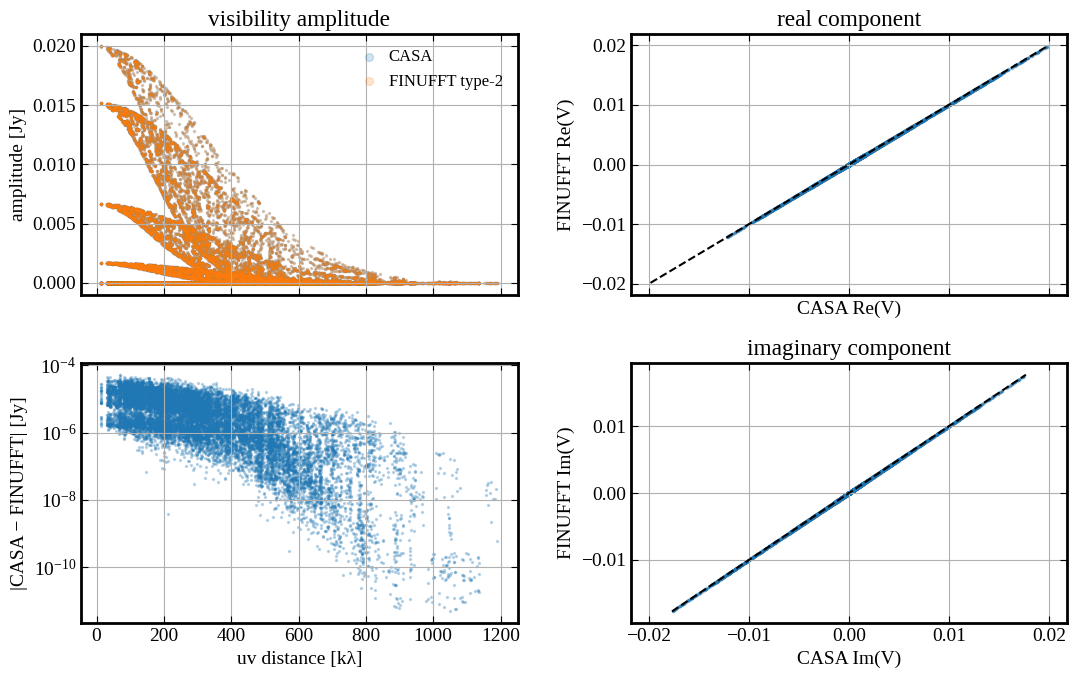

In [6]:
casa_cube, uv_signal = casa_cube_for_ms(SIGNAL_MS)
finufft_signal, signal_observation = model_visibilities(casa_cube, uv_signal)
casa_signal = signal_observation.data
fft_residual = casa_signal - finufft_signal
fft_relative_rms = relative_rms(fft_residual, casa_signal)
fft_peak_fraction = np.max(np.abs(fft_residual)) / np.max(np.abs(casa_signal))
# PB近似そのものが残差を作っていないか、同じCASA modelをPBなしでも比較する。
finufft_without_pb, _ = model_visibilities(casa_cube, uv_signal, apply_primary_beam=False)
fft_relative_rms_without_pb = relative_rms(casa_signal - finufft_without_pb, casa_signal)
print(f'unflagged complex visibilities: {casa_signal.size:,}')
print(f'relative RMS residual       : {fft_relative_rms:.3e}')
print(f'max residual / peak |V|    : {fft_peak_fraction:.3e}')
print(f'relative RMS without PB    : {fft_relative_rms_without_pb:.3e}')

uv_radius = flatten_like(
    signal_observation, np.hypot(uv_signal['uvw_lam'][0], uv_signal['uvw_lam'][1])
) / 1e3

# ランダムにサンプリングしてプロとット
rng = np.random.default_rng(SEED)
show = rng.choice(casa_signal.size, min(30000, casa_signal.size), replace=False)
fig, ax = plt.subplots(2, 2, figsize=(11, 7), sharex='col')
ax[0, 0].scatter(uv_radius[show], np.abs(casa_signal[show]), s=2, alpha=.2, label='CASA')
ax[0, 0].scatter(uv_radius[show], np.abs(finufft_signal[show]), s=2, alpha=.2, label='FINUFFT type-2')
ax[0, 0].set(ylabel='amplitude [Jy]', title='visibility amplitude'); ax[0, 0].legend(markerscale=4)
ax[1, 0].scatter(uv_radius[show], np.abs(fft_residual[show]), s=2, alpha=.25)
ax[1, 0].set(xlabel='uv distance [kλ]', ylabel='|CASA − FINUFFT| [Jy]', yscale='log')
ax[0, 1].scatter(casa_signal.real[show], finufft_signal.real[show], s=2, alpha=.2)
lim = np.max(np.abs(casa_signal.real)); ax[0, 1].plot([-lim, lim], [-lim, lim], 'k--')
ax[0, 1].set(xlabel='CASA Re(V)', ylabel='FINUFFT Re(V)', title='real component')
ax[1, 1].scatter(casa_signal.imag[show], finufft_signal.imag[show], s=2, alpha=.2)
lim = np.max(np.abs(casa_signal.imag)); ax[1, 1].plot([-lim, lim], [-lim, lim], 'k--')
ax[1, 1].set(xlabel='CASA Im(V)', ylabel='FINUFFT Im(V)', title='imaginary component')
ax[0, 0].grid(); ax[1, 0].grid(); ax[0, 1].grid(); ax[1, 1].grid()
plt.tight_layout(); plt.show()

ランダムチャンネルから選んでいるので、チャンネルによってampが異なる

## 1b. 現行NUFFT dirty image と CASA tclean の比較

同じnoiseなしMSを、CASA `tclean`（`natural`, `niter=0`, `gridder='standard'`）と `glint.interferometer.vis_to_image_finufft_type1` でdirty imagingする。同じ128×128、0.03 arcsec pixel、channelごとのMS weightを使い、中央channelの画像・差分・peak位置を比較

type-1 NUFFT vs tclean dirty relative RMS  : 1.209e-03
type-1 NUFFT vs tclean dirty correlation   : 0.999999
max |dirty difference| / CASA peak         : 7.404e-04
NUFFT vs tclean PSF relative RMS           : 1.251e-03
central-channel peak (y, x), NUFFT / CASA  : (np.int64(58), np.int64(73)) / (np.int64(58), np.int64(73))


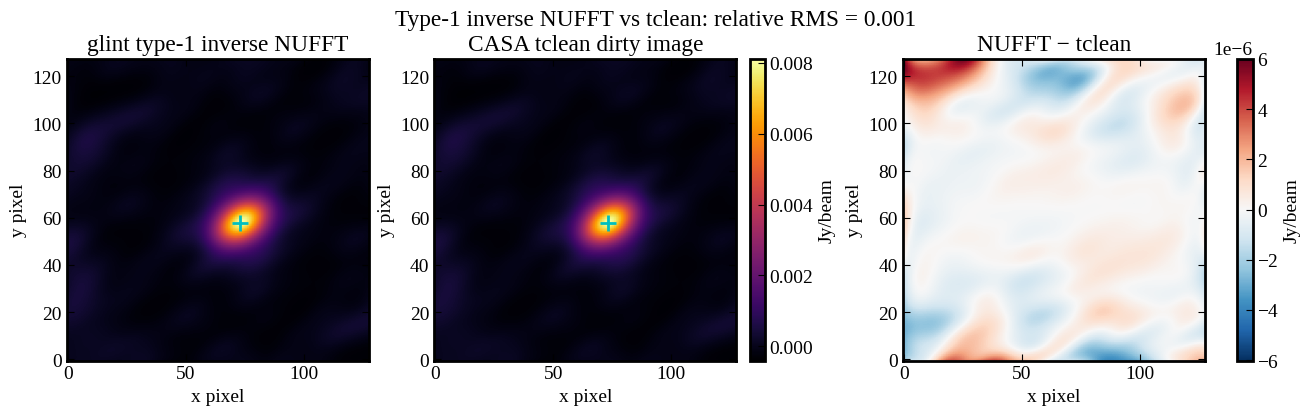

In [7]:
from casatasks import tclean
from glint.interferometer import vis_to_image_finufft_type1

TCLEAN_PREFIX = WORK / 'casa_dirty_noiseless'
TCLEAN_RESIDUAL = Path(f'{TCLEAN_PREFIX}.residual')
TCLEAN_PSF = Path(f'{TCLEAN_PREFIX}.psf')
TCLEAN_RESIDUAL_FITS = Path(f'{TCLEAN_PREFIX}.residual.fits')
TCLEAN_PSF_FITS = Path(f'{TCLEAN_PREFIX}.psf.fits')

if not TCLEAN_RESIDUAL.exists():
    tclean(
        vis=str(SIGNAL_MS), imagename=str(TCLEAN_PREFIX),
        imsize=[NX, NY], cell=f'{PIXEL_ARCSEC}arcsec',
        weighting='natural', niter=0, stokes='I',
        specmode='cube', start=0, width=1, nchan=NCHAN,
        gridder='standard', pblimit=-1, interactive=False,
        calcpsf=True, calcres=True, restoration=False, parallel=False,
    )
if not TCLEAN_RESIDUAL_FITS.exists():
    exportfits(
        imagename=str(TCLEAN_RESIDUAL),
        fitsimage=str(TCLEAN_RESIDUAL_FITS),
        dropdeg=True, overwrite=True,
    )
if not TCLEAN_PSF_FITS.exists():
    exportfits(
        imagename=str(TCLEAN_PSF),
        fitsimage=str(TCLEAN_PSF_FITS),
        dropdeg=True, overwrite=True,
    )

casa_tclean_dirty = np.squeeze(fits.getdata(TCLEAN_RESIDUAL_FITS)).astype(np.float32)
casa_tclean_psf = np.squeeze(fits.getdata(TCLEAN_PSF_FITS)).astype(np.float32)
current_nufft_dirty = np.empty_like(casa_tclean_dirty)
current_nufft_psf = np.empty_like(casa_tclean_psf)
for channel in range(NCHAN):
    good = ~uv_signal['flag'][channel]
    current_nufft_dirty[channel], current_nufft_psf[channel] = vis_to_image_finufft_type1(
        u=uv_signal['uvw_lam'][0, channel, good],
        v=uv_signal['uvw_lam'][1, channel, good],
        V=uv_signal['data'][channel, good],
        V_weight=uv_signal['weight'][channel, good],
        image_shape=(NY, NX), ps_arcsec=PIXEL_ARCSEC, eps=1e-6,
    )

tclean_dirty_delta = current_nufft_dirty - casa_tclean_dirty
tclean_dirty_relative_rms = relative_rms(tclean_dirty_delta, casa_tclean_dirty)
tclean_dirty_correlation = np.corrcoef(
    current_nufft_dirty.ravel(), casa_tclean_dirty.ravel()
)[0, 1]
tclean_dirty_max_fraction = (
    np.max(np.abs(tclean_dirty_delta)) / np.max(np.abs(casa_tclean_dirty))
)
tclean_psf_relative_rms = relative_rms(
    current_nufft_psf - casa_tclean_psf, casa_tclean_psf
)

central_channel = NCHAN // 2
nufft_peak_yx = np.unravel_index(
    np.argmax(current_nufft_dirty[central_channel]),
    current_nufft_dirty[central_channel].shape,
)
casa_peak_yx = np.unravel_index(
    np.argmax(casa_tclean_dirty[central_channel]),
    casa_tclean_dirty[central_channel].shape,
)
print(f'type-1 NUFFT vs tclean dirty relative RMS  : {tclean_dirty_relative_rms:.3e}')
print(f'type-1 NUFFT vs tclean dirty correlation   : {tclean_dirty_correlation:.6f}')
print(f'max |dirty difference| / CASA peak         : {tclean_dirty_max_fraction:.3e}')
print(f'NUFFT vs tclean PSF relative RMS           : {tclean_psf_relative_rms:.3e}')
print(f'central-channel peak (y, x), NUFFT / CASA  : {nufft_peak_yx} / {casa_peak_yx}')

nufft_plane = current_nufft_dirty[central_channel]
casa_plane = casa_tclean_dirty[central_channel]
delta_plane = tclean_dirty_delta[central_channel]
image_vmax = max(np.max(np.abs(nufft_plane)), np.max(np.abs(casa_plane)))
delta_vmax = np.max(np.abs(delta_plane))

# plot
fig, ax = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
im0 = ax[0].imshow(
    nufft_plane, origin='lower', cmap='inferno',
    vmin=-0.05 * image_vmax, vmax=image_vmax,
)
im1 = ax[1].imshow(
    casa_plane, origin='lower', cmap='inferno',
    vmin=-0.05 * image_vmax, vmax=image_vmax,
)
im2 = ax[2].imshow(
    delta_plane, origin='lower', cmap='RdBu_r',
    vmin=-delta_vmax, vmax=delta_vmax,
)
ax[0].plot(nufft_peak_yx[1], nufft_peak_yx[0], 'c+', ms=12, mew=2)
ax[1].plot(casa_peak_yx[1], casa_peak_yx[0], 'c+', ms=12, mew=2)
ax[0].set_title('glint type-1 inverse NUFFT')
ax[1].set_title('CASA tclean dirty image')
ax[2].set_title('NUFFT − tclean')
for axis in ax:
    axis.set(xlabel='x pixel', ylabel='y pixel')
fig.colorbar(im1, ax=ax[:2], label='Jy/beam', fraction=0.025, pad=0.02)
fig.colorbar(im2, ax=ax[2], label='Jy/beam', fraction=0.05, pad=0.03)
fig.suptitle(
    f'Type-1 inverse NUFFT vs tclean: '
    f'relative RMS = {tclean_dirty_relative_rms:.3f}',
)
plt.show()


## 2. baseline-dependent time averagingの影響

CASAが平均したsignal visibilityと、平均後MSに保存された代表uv座標でFINUFFTを1回評価した値を比較する。row削減率も記録する。

In [8]:
base_rows = uv_signal['uvw_m'].shape[1]
time_average_rows = []
averaged_products = {}

# mstransformで時間平均
for max_uv_m in MAX_UV_DISTANCES_M:
    tag = f'{max_uv_m:g}m'
    signal_avg_ms = WORK / f'signal_avg_{tag}.ms'
    noisy_avg_ms = WORK / f'noisy_avg_{tag}.ms'
    average_ms(SIGNAL_MS, signal_avg_ms, max_uv_m)
    average_ms(NOISY_MS, noisy_avg_ms, max_uv_m)

    uv_avg = load_uv(signal_avg_ms) # 時間平均したMSのUV情報をロード
    model_avg, avg_observation = model_visibilities(casa_cube, uv_avg) # model_avgは、真のsky modelを時間平均したUVで観測した場合のvisibility、avg_observationは、時間平均したMSの観測値（data/sigma/flag）を含むUVContext
    data_avg = avg_observation.data
    delta = data_avg - model_avg # uv_avgのデータだが、build_uv_observationでflagとか考慮してる
    nrows = uv_avg['uvw_m'].shape[1]
    time_average_rows.append({
        'max_uv_distance_m': max_uv_m,
        'MS_rows': nrows,
        'row_fraction': nrows / base_rows,
        'max_residual_over_peak': np.max(np.abs(delta)) / np.max(np.abs(data_avg)),
    })
    averaged_products[max_uv_m] = (signal_avg_ms, noisy_avg_ms)

time_average_table = pd.DataFrame(time_average_rows)


## 平均後のnoiseとtime-averaging誤差の比較

`max_uv_distance`ごとに平均した後のMSについて、`noisy − signal`（真のnoiseそのもの）をline-free
channelだけ取り出し、その標準偏差からCASA `WEIGHT`の較正係数を測り直す（平均するとnoiseレベルが
変わるため、設定ごとに較正し直す必要がある）。この較正済みnoiseを基準に、section 2で見た
「代表uv点1点でのモデル評価」の誤差（`delta`）が何倍かを`RMS_model_error_over_sigma`として計算する。

左：row数の圧縮率（section 2の`row_fraction`の再掲）。右：モデル評価誤差 / thermal noise σ。
右側が十分小さければ（目安0.1σ未満、破線）、その`max_uv_distance`はStage 4のfitに安全に使える。

,max_uv_distance_m,MS_rows,row_fraction,max_residual_over_peak,weight_scale,std_normalized_noise,skewness,excess_kurtosis,tail_|z|>3,RMS_model_error_over_sigma
0,3.000000,2.234e+04,0.06874,0.002335,0.1124,1,-0.0001102,-0.007351,0.002649,0.0001516
1,6.000000,1.165e+04,0.03585,0.002052,0.1126,1,-0.006269,0.006507,0.002671,0.0002018
2,12.000000,6132,0.01886,0.002046,0.1121,1,-0.01144,0.006191,0.00267,0.0002593
3,24.000000,3311,0.01019,0.001879,0.1122,1,-0.03337,0.007695,0.002982,0.00034
4,48.000000,1886,0.005802,0.00288,0.1118,1,-0.02438,0.004261,0.003016,0.0007241


/tmp/ipykernel_1666440/2844799268.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(); plt.tight_layout(); plt.show()


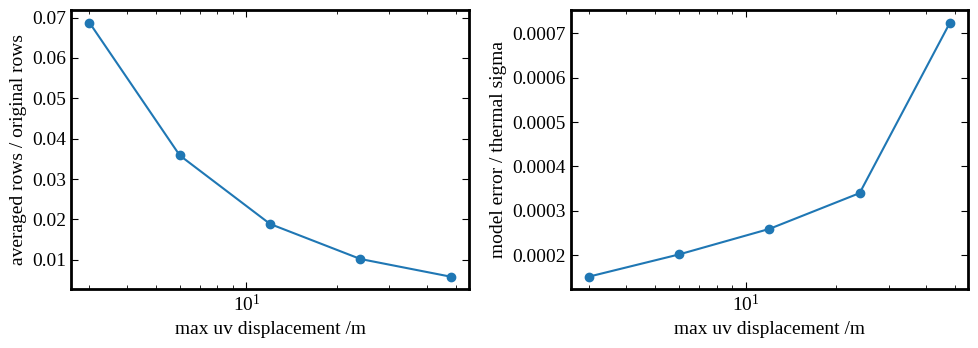

In [9]:
noise_rows = []
for max_uv_m, (signal_avg_ms, noisy_avg_ms) in averaged_products.items():
    us = load_uv(signal_avg_ms)
    un = load_uv(noisy_avg_ms)
    valid = ~(us['flag'] | un['flag'])
    lf = np.zeros_like(valid); lf[LINE_FREE] = valid[LINE_FREE]
    noise = (un['data'] - us['data'])[lf]
    sigma = un['sigma'][lf]
    scale = np.sqrt(np.mean(np.abs(noise / sigma)**2) / 2.0)
    summary = noise_gaussianity_summary(noise / (sigma * scale))

    model, avg_signal_observation = model_visibilities(casa_cube, us)
    signal = avg_signal_observation.data
    model_error = signal - model
    sigma_all = flatten_like(avg_signal_observation, un['sigma']) * scale
    noise_rows.append({
        'max_uv_distance_m': max_uv_m,
        'weight_scale': scale,
        'std_normalized_noise': 0.5 * (summary['std Re/sigma'] + summary['std Im/sigma']),
        'skewness': summary['skewness'],
        'excess_kurtosis': summary['excess kurtosis'],
        'tail_|z|>3': summary['fraction |z| > 3'],
        'RMS_model_error_over_sigma': np.sqrt(np.mean(np.abs(model_error / sigma_all)**2) / 2.0),
    })

noise_average_table = pd.DataFrame(noise_rows)
combined_table = time_average_table.merge(noise_average_table, on='max_uv_distance_m')
display(combined_table.style.format({c: '{:.4g}' for c in combined_table.columns if c != 'max_uv_distance_m'}))

# row削減率とthermal sigma基準の誤差
fig, ax = plt.subplots(1, 2, figsize=(10, 3.7))
ax[0].plot(time_average_table.max_uv_distance_m, time_average_table.row_fraction, 'o-')
ax[0].set(xlabel='max uv displacement /m', ylabel='averaged rows / original rows', xscale='log')
ax[1].plot(noise_average_table.max_uv_distance_m, noise_average_table.RMS_model_error_over_sigma, 'o-')
ax[1].set(xlabel='max uv displacement /m', ylabel='model error / thermal sigma', xscale='log')
ax[1].legend(); plt.tight_layout(); plt.show()

## 3. line-free channelのnoise分布とMS WEIGHT

line-free channelのノイズがGaussianであることを一応確認する  
CASAの`σ=1/sqrt(WEIGHT)`で規格化した実部・虚部を調べる。絶対weight scaleにずれがある場合はline-free dataから1個のscale factorだけを測り、その後のGaussian性を評価する。

標本数が非常に多いとnormality testのp値は微小な非Gaussian性にも反応するため、skewness、excess kurtosis、1–3σ tail fraction、Q–Q plotを主に見る。

,value
sigma calibration factor,1.123565e-01
complex samples,2.600640e+06
mean Re/sigma,-2.251236e-04
std Re/sigma,9.996658e-01
mean Im/sigma,5.152401e-04
std Im/sigma,1.000334e+00
"corr(Re, Im)",3.848598e-04
skewness,1.404763e-03
excess kurtosis,-2.539273e-03
fraction |z| > 1,3.173523e-01


Gaussian expectations: |z|>1,2,3 = 0.31731, 0.04550, 0.00270


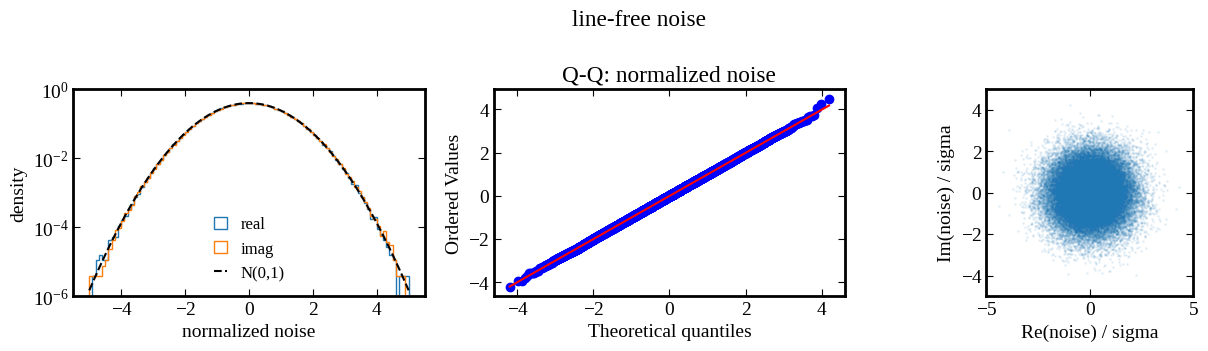

In [10]:
uv_noisy = load_uv(NOISY_MS)
if not np.array_equal(uv_noisy['flag'], uv_signal['flag']):
    warnings.warn('signal/noisy MSのflagが一致しないため共通unflagged sampleだけを使う')
common = ~(uv_noisy['flag'] | uv_signal['flag'])
noise_cube = uv_noisy['data'] - uv_signal['data']
lf_mask = np.zeros_like(common)
lf_mask[LINE_FREE] = common[LINE_FREE]
lf_noise = noise_cube[lf_mask]
lf_sigma = uv_noisy['sigma'][lf_mask] # MSのweightの逆二乗

# CASA sigmaの絶対scaleをline-free channelだけから較正する。
weight_scale = np.sqrt(np.mean(np.abs(lf_noise / lf_sigma)**2) / 2.0)
z_complex = lf_noise / (lf_sigma * weight_scale)

# Gaussian
noise_summary = pd.Series({'sigma calibration factor': weight_scale,
                           **noise_gaussianity_summary(z_complex)})
display(noise_summary.to_frame('value'))
print('Gaussian expectations: |z|>1,2,3 = 0.31731, 0.04550, 0.00270')
fig = plot_noise_gaussianity(z_complex, seed=SEED, title='line-free noise')
plt.show()


## 4. 異なる2つのALMA観測の結合とstatwt

同じsky modelを観測A（Cycle 7.5、10 s integration、3600 s）と観測B（Cycle 7.8、30 s integration、1800 s）で独立に観測する。configuration、積分時間、総観測時間、hour angle、noise seedを変える。観測Aには上で作成したMSを再利用し、観測Bだけを追加生成する。

次の2通りを比較する。

1. pipeline/simobserveの元のWEIGHTのまま2つのnoisy MSを`concat`
2. 各MSのline-free channelだけで`statwt`してから`concat`

`statwt`は入力MSを書き換えるので、専用コピーにだけ適用する。

In [11]:
from casatasks import concat, statwt

PROJECT_B = WORK / 'gaussian_test_config8'
INTEGRATION_B = '30s'
TOTAL_TIME_B = '1800s'
CONFIG_B = Path('../data/configuration_files/alma.cycle7.8.cfg')
ANTENNA_CONFIG_B = CONFIG_B.resolve()

existing_signal_b = sorted(
    path for path in PROJECT_B.glob('*.ms')
    if not path.name.endswith('.noisy.ms')
)
existing_noisy_b = sorted(PROJECT_B.glob('*.noisy.ms'))
if len(existing_signal_b) != 1 or len(existing_noisy_b) != 1:
    notebook_dir = Path.cwd()
    try:
        os.chdir(WORK)
        simobserve(
            project=PROJECT_B.name, skymodel=str(INPUT_FITS),
            indirection='J2000 00h00m00.0s +00d00m00.0s',
            incell=f'{PIXEL_ARCSEC}arcsec',
            incenter=f'{CENTER_FREQ_HZ}Hz',
            inwidth=f'{CHANNEL_WIDTH_HZ}Hz',
            setpointings=True, integration=INTEGRATION_B,
            direction='J2000 00h00m00.0s +00d00m00.0s',
            obsmode='int', antennalist=str(ANTENNA_CONFIG_B),
            refdate='2022/02/15', hourangle='1h',
            totaltime=TOTAL_TIME_B, thermalnoise='tsys-atm',
            user_pwv=0.5, t_ground=270.0, seed=SEED + 1,
            leakage=0.0, graphics='none', verbose=False, overwrite=True,
        )
    finally:
        os.chdir(notebook_dir)

signal_candidates_b = sorted(
    path for path in PROJECT_B.glob('*.ms')
    if not path.name.endswith('.noisy.ms')
)
noisy_candidates_b = sorted(PROJECT_B.glob('*.noisy.ms'))
if len(signal_candidates_b) != 1 or len(noisy_candidates_b) != 1:
    raise RuntimeError(
        f'unexpected observation-B products: '
        f'{signal_candidates_b}, {noisy_candidates_b}'
    )
SIGNAL_MS_B, NOISY_MS_B = signal_candidates_b[0], noisy_candidates_b[0]

uv_signal_b = load_uv(SIGNAL_MS_B)
uv_noisy_b = load_uv(NOISY_MS_B)
observation_setup = pd.DataFrame([
    {
        'observation': 'A',
        'configuration': 'alma.cycle7.5',
        'integration_s': 10,
        'total_time_s': 3600,
        'MS_rows': uv_signal['uvw_m'].shape[1],
        'max_baseline_m': np.max(np.hypot(
            uv_signal['uvw_m'][0], uv_signal['uvw_m'][1]
        )),
    },
    {
        'observation': 'B',
        'configuration': 'alma.cycle7.8',
        'integration_s': 30,
        'total_time_s': 1800,
        'MS_rows': uv_signal_b['uvw_m'].shape[1],
        'max_baseline_m': np.max(np.hypot(
            uv_signal_b['uvw_m'][0], uv_signal_b['uvw_m'][1]
        )),
    },
])
display(observation_setup.style.format({'max_baseline_m': '{:.1f}'}))
print('observation A:', SIGNAL_MS.name, '/', NOISY_MS.name)
print('observation B:', SIGNAL_MS_B.name, '/', NOISY_MS_B.name)


,observation,configuration,integration_s,total_time_s,MS_rows,max_baseline_m
0,A,alma.cycle7.5,10,3600,325080,1325.8
1,B,alma.cycle7.8,30,1800,54180,8088.9


observation A: gaussian_test.alma.cycle7.5.ms / gaussian_test.alma.cycle7.5.noisy.ms
observation B: gaussian_test_config8.alma.cycle7.8.ms / gaussian_test_config8.alma.cycle7.8.noisy.ms


### 元のWEIGHTとstatwt後のWEIGHT

noisy−noiselessで真のthermal noiseを分離する。`noise / (1/sqrt(WEIGHT))`
の実部・虚部のRMSから`sigma calibration factor`を測る。理想値は1で、
2観測のfactorが同じなら、絶対scaleがずれていても相対weightは正しい。

`statwt`にはsignalがゼロのchannel `0~3, 11~14`だけを使い、全scanの
time sampleと2 correlationをbaselineごとに集約する。このsimobserve MSでは
`tclean`が`CORRECTED_DATA`に対応する`WEIGHT`を使うため、`statwt`にも
`datacolumn='corrected'`を指定する。入力MSを直接変更せず、専用コピーだけを
処理する。

In [12]:
STATWT_WORK = WORK / 'statwt_two_observation'
STATWT_WORK.mkdir(parents=True, exist_ok=True)
STATWT_A_MS = STATWT_WORK / 'observation_A.noisy.statwt_corrected.ms'
STATWT_B_MS = STATWT_WORK / 'observation_B.noisy.statwt_corrected.ms'
LINE_FREE_FITSPW = '0:0~3;11~14'

def prepare_statwt_copy(source_ms, target_ms):
    done_marker = Path(f'{target_ms}.done')
    if done_marker.exists():
        return
    if not target_ms.exists():
        shutil.copytree(source_ms, target_ms)
    statwt(
        vis=str(target_ms), datacolumn='corrected',
        fitspw=LINE_FREE_FITSPW, combine='corr',
        timebin='10000000s', chanbin='spw', minsamp=2,
        statalg='classic', flagbackup=False, preview=False,
    )
    done_marker.touch()

def noise_weight_diagnostic(label, signal_ms, noisy_ms, weight_state):
    signal_uv = load_uv(signal_ms)
    noisy_uv = load_uv(noisy_ms)
    valid = ~(signal_uv['flag'] | noisy_uv['flag'])
    line_free = np.zeros_like(valid)
    line_free[LINE_FREE] = valid[LINE_FREE]
    noise = (noisy_uv['data'] - signal_uv['data'])[line_free]
    sigma = noisy_uv['sigma'][line_free]
    scale = np.sqrt(np.mean(np.abs(noise / sigma)**2) / 2.0)
    return {
        'observation': label,
        'weight_state': weight_state,
        'complex_samples': noise.size,
        'sigma_calibration_factor': scale,
        'empirical_component_sigma_Jy': np.sqrt(
            np.mean(np.abs(noise)**2) / 2.0
        ),
        'median_sigma_from_WEIGHT_Jy': np.median(sigma),
        'median_Stokes_WEIGHT': np.median(
            noisy_uv['weight'][line_free]
        ),
    }

raw_weight_rows = [
    noise_weight_diagnostic('A', SIGNAL_MS, NOISY_MS, 'original'),
    noise_weight_diagnostic('B', SIGNAL_MS_B, NOISY_MS_B, 'original'),
]
prepare_statwt_copy(NOISY_MS, STATWT_A_MS)
prepare_statwt_copy(NOISY_MS_B, STATWT_B_MS)
statwt_weight_rows = [
    noise_weight_diagnostic('A', SIGNAL_MS, STATWT_A_MS, 'statwt'),
    noise_weight_diagnostic('B', SIGNAL_MS_B, STATWT_B_MS, 'statwt'),
]
weight_diagnostic_table = pd.DataFrame(
    raw_weight_rows + statwt_weight_rows
)
display(weight_diagnostic_table.style.format({
    'sigma_calibration_factor': '{:.4f}',
    'empirical_component_sigma_Jy': '{:.4e}',
    'median_sigma_from_WEIGHT_Jy': '{:.4e}',
    'median_Stokes_WEIGHT': '{:.4e}',
}))

raw_scales = weight_diagnostic_table.query(
    "weight_state == 'original'"
).set_index('observation').sigma_calibration_factor
statwt_scales = weight_diagnostic_table.query(
    "weight_state == 'statwt'"
).set_index('observation').sigma_calibration_factor
raw_relative_scale_ratio = raw_scales.max() / raw_scales.min()
statwt_relative_scale_ratio = statwt_scales.max() / statwt_scales.min()
print(f'original A/B calibration-factor spread : {raw_relative_scale_ratio:.4f}')
print(f'statwt   A/B calibration-factor spread : {statwt_relative_scale_ratio:.4f}')


,observation,weight_state,complex_samples,sigma_calibration_factor,empirical_component_sigma_Jy,median_sigma_from_WEIGHT_Jy,median_Stokes_WEIGHT
0,A,original,2600640,0.1124,7.9448e-02,7.0711e-01,2.0000e+00
1,B,original,433440,0.0653,4.6185e-02,7.0711e-01,2.0000e+00
2,A,statwt,2600640,1.0004,7.9448e-02,7.9415e-02,1.5856e+02
3,B,statwt,433440,1.0014,4.6185e-02,4.6142e-02,4.6968e+02


original A/B calibration-factor spread : 1.7202
statwt   A/B calibration-factor spread : 1.0011


### concat後のnatural-weight dirty image

元WEIGHTの2観測と、各観測を`statwt`した2観測をそれぞれ`concat`し、同じ`tclean(niter=0, weighting='natural')`でdirty cubeを作る。line-free channelの画像RMSと、結合MSのWEIGHTが予測する`1/sqrt(sum WEIGHT)`を比較する。

,weights,measured_line_free_image_RMS_Jy_beam,predicted_RMS_from_WEIGHT_Jy_beam,measured/predicted
0,original,1.2004e-04,1.1482e-03,0.1046
1,statwt,1.1236e-04,1.1393e-04,0.9862


statwt/original measured image RMS       : 0.9360
central science-channel relative change : 1.9629e-01


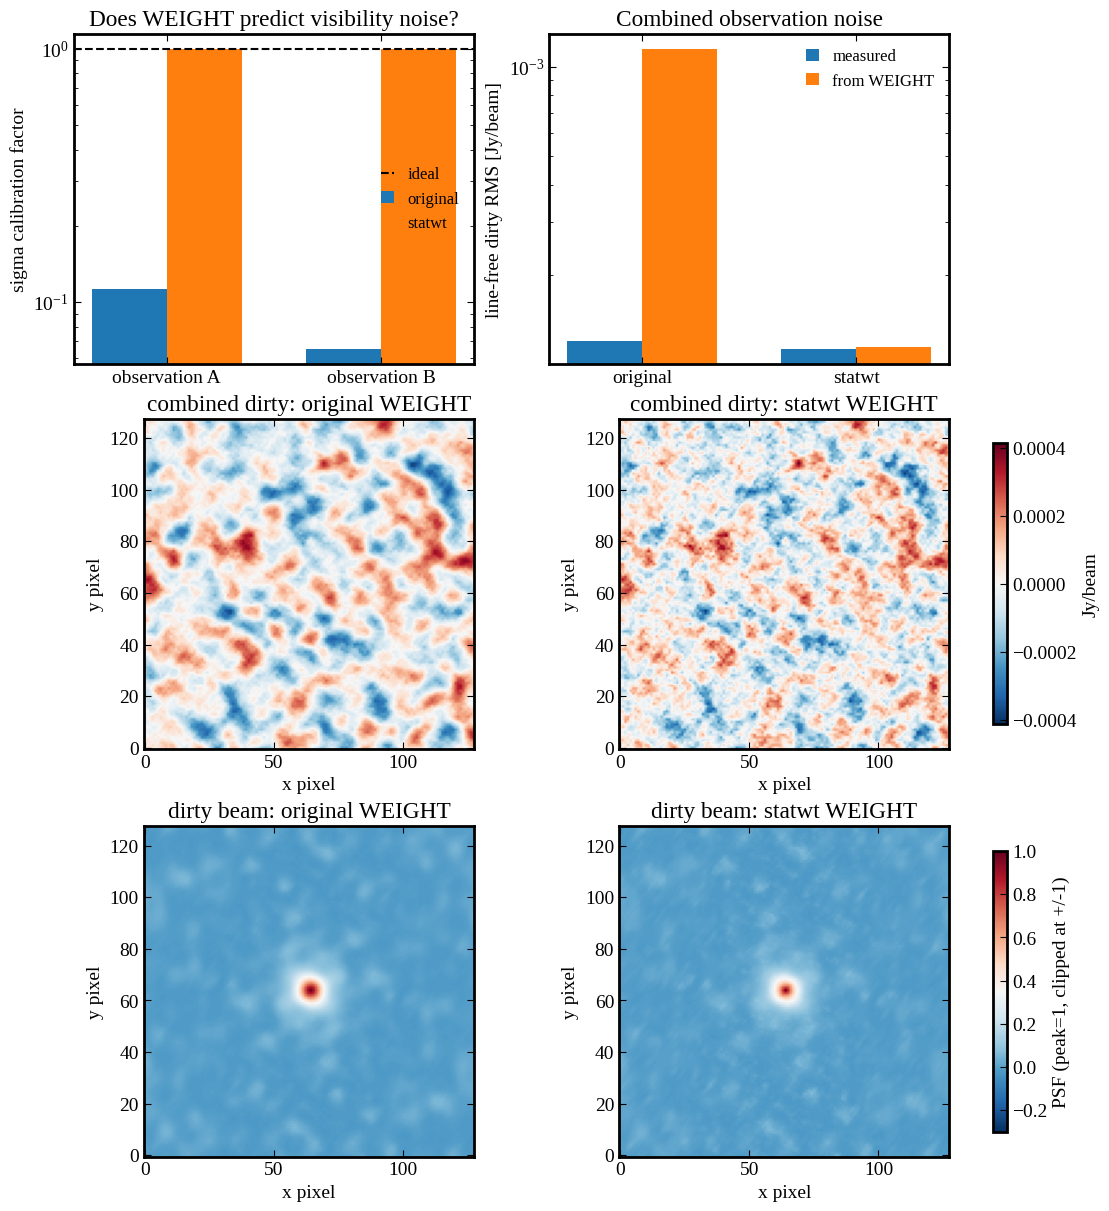

In [13]:
RAW_COMBINED_MS = STATWT_WORK / 'combined_original_weights.ms'
STATWT_COMBINED_MS = STATWT_WORK / 'combined_statwt_corrected_weights.ms'
if not RAW_COMBINED_MS.exists():
    concat(
        vis=[str(NOISY_MS), str(NOISY_MS_B)],
        concatvis=str(RAW_COMBINED_MS),
        timesort=True, copypointing=False,
    )
if not STATWT_COMBINED_MS.exists():
    concat(
        vis=[str(STATWT_A_MS), str(STATWT_B_MS)],
        concatvis=str(STATWT_COMBINED_MS),
        timesort=True, copypointing=False,
    )

def make_combined_dirty(ms_path, tag):
    """dirty residual画像と、比較用のdirty beam（PSF）を両方返す。"""
    prefix = STATWT_WORK / f'combined_{tag}_dirty'
    residual = Path(f'{prefix}.residual')
    psf = Path(f'{prefix}.psf')
    residual_fits = Path(f'{prefix}.residual.fits')
    psf_fits = Path(f'{prefix}.psf.fits')
    if not residual.exists():
        tclean(
            vis=str(ms_path), imagename=str(prefix),
            imsize=[NX, NY], cell=f'{PIXEL_ARCSEC}arcsec',
            weighting='natural', niter=0, stokes='I',
            specmode='cube', start=0, width=1, nchan=NCHAN,
            gridder='standard', pblimit=-1, interactive=False,
            calcpsf=True, calcres=True, restoration=False, parallel=False,
        )
    if not residual_fits.exists():
        exportfits(
            imagename=str(residual), fitsimage=str(residual_fits),
            dropdeg=True, overwrite=True,
        )
    if not psf_fits.exists():
        exportfits(
            imagename=str(psf), fitsimage=str(psf_fits),
            dropdeg=True, overwrite=True,
        )
    dirty = np.squeeze(fits.getdata(residual_fits)).astype(np.float32)
    beam = np.squeeze(fits.getdata(psf_fits)).astype(np.float32)
    return dirty, beam

def channel_weight_sum(ms_path):
    from casatools import table
    table_tool = table()
    try:
        table_tool.open(str(ms_path))
        flag_pol = np.asarray(table_tool.getcol('FLAG'), dtype=bool)
        weight_pol = np.asarray(table_tool.getcol('WEIGHT'), dtype=float)
        weight_spectrum = None
        if 'WEIGHT_SPECTRUM' in table_tool.colnames():
            try:
                candidate = np.asarray(
                    table_tool.getcol('WEIGHT_SPECTRUM'), dtype=float
                )
                if candidate.shape == flag_pol.shape and np.any(candidate > 0):
                    weight_spectrum = candidate
            except Exception:
                weight_spectrum = None
    finally:
        table_tool.close()
    if weight_spectrum is None:
        weight_spectrum = np.broadcast_to(
            weight_pol[:, None, :], flag_pol.shape
        )
    return np.sum(np.where(flag_pol, 0.0, weight_spectrum), axis=(0, 2))

raw_combined_dirty, raw_combined_beam = make_combined_dirty(
    RAW_COMBINED_MS, 'original_weights'
)
statwt_combined_dirty, statwt_combined_beam = make_combined_dirty(
    STATWT_COMBINED_MS, 'statwt_corrected_weights_verified'
)
inner_slice = np.s_[16:-16, 16:-16]

def line_free_image_rms(cube):
    channel_rms = np.array([
        np.std(cube[channel][inner_slice]) for channel in LINE_FREE
    ])
    return np.sqrt(np.mean(channel_rms**2))

raw_image_rms = line_free_image_rms(raw_combined_dirty)
statwt_image_rms = line_free_image_rms(statwt_combined_dirty)
raw_weight_sum = channel_weight_sum(RAW_COMBINED_MS)
statwt_weight_sum = channel_weight_sum(STATWT_COMBINED_MS)
raw_predicted_rms = np.sqrt(np.mean(
    (1.0 / np.sqrt(raw_weight_sum[LINE_FREE]))**2
))
statwt_predicted_rms = np.sqrt(np.mean(
    (1.0 / np.sqrt(statwt_weight_sum[LINE_FREE]))**2
))
raw_measured_over_predicted = raw_image_rms / raw_predicted_rms
statwt_measured_over_predicted = statwt_image_rms / statwt_predicted_rms
combined_noise_ratio = statwt_image_rms / raw_image_rms
central_science_relative_change = relative_rms(
    statwt_combined_dirty[NCHAN // 2] - raw_combined_dirty[NCHAN // 2],
    raw_combined_dirty[NCHAN // 2],
)

combined_weight_table = pd.DataFrame([
    {
        'weights': 'original',
        'measured_line_free_image_RMS_Jy_beam': raw_image_rms,
        'predicted_RMS_from_WEIGHT_Jy_beam': raw_predicted_rms,
        'measured/predicted': raw_measured_over_predicted,
    },
    {
        'weights': 'statwt',
        'measured_line_free_image_RMS_Jy_beam': statwt_image_rms,
        'predicted_RMS_from_WEIGHT_Jy_beam': statwt_predicted_rms,
        'measured/predicted': statwt_measured_over_predicted,
    },
])
display(combined_weight_table.style.format({
    'measured_line_free_image_RMS_Jy_beam': '{:.4e}',
    'predicted_RMS_from_WEIGHT_Jy_beam': '{:.4e}',
    'measured/predicted': '{:.4f}',
}))
print(f'statwt/original measured image RMS       : {combined_noise_ratio:.4f}')
print(f'central science-channel relative change : {central_science_relative_change:.4e}')

fig, ax = plt.subplots(3, 2, figsize=(11, 12), constrained_layout=True)
x = np.arange(2)
width = 0.35
ax[0, 0].bar(x - width/2, raw_scales[['A', 'B']], width, label='original')
ax[0, 0].bar(x + width/2, statwt_scales[['A', 'B']], width, label='statwt')
ax[0, 0].axhline(1.0, color='k', ls='--', label='ideal')
ax[0, 0].set(
    xticks=x, xticklabels=['observation A', 'observation B'],
    ylabel='sigma calibration factor', yscale='log',
    title='Does WEIGHT predict visibility noise?',
)
ax[0, 0].legend()

x2 = np.arange(2)
measured = [raw_image_rms, statwt_image_rms]
predicted = [raw_predicted_rms, statwt_predicted_rms]
ax[0, 1].bar(x2 - width/2, measured, width, label='measured')
ax[0, 1].bar(x2 + width/2, predicted, width, label='from WEIGHT')
ax[0, 1].set(
    xticks=x2, xticklabels=['original', 'statwt'],
    ylabel='line-free dirty RMS [Jy/beam]', yscale='log',
    title='Combined observation noise',
)
ax[0, 1].legend()

line_free_channel = int(LINE_FREE[0])
image_limit = max(
    np.max(np.abs(raw_combined_dirty[line_free_channel])),
    np.max(np.abs(statwt_combined_dirty[line_free_channel])),
)
im0 = ax[1, 0].imshow(
    raw_combined_dirty[line_free_channel], origin='lower',
    cmap='RdBu_r', vmin=-image_limit, vmax=image_limit,
)
im1 = ax[1, 1].imshow(
    statwt_combined_dirty[line_free_channel], origin='lower',
    cmap='RdBu_r', vmin=-image_limit, vmax=image_limit,
)
ax[1, 0].set_title('combined dirty: original WEIGHT')
ax[1, 1].set_title('combined dirty: statwt WEIGHT')
for axis in ax[1]:
    axis.grid(False)
    axis.set(xlabel='x pixel', ylabel='y pixel')
fig.colorbar(im1, ax=ax[1], label='Jy/beam', shrink=0.85)

psf_clip = 1
im2 = ax[2, 0].imshow(
    raw_combined_beam[line_free_channel], origin='lower',
    cmap='RdBu_r', vmin=-0.3, vmax=psf_clip,
)
im3 = ax[2, 1].imshow(
    statwt_combined_beam[line_free_channel], origin='lower',
    cmap='RdBu_r', vmin=-0.3, vmax=psf_clip,
)
ax[2, 0].set_title('dirty beam: original WEIGHT')
ax[2, 1].set_title('dirty beam: statwt WEIGHT')
for axis in ax[2]:
    axis.grid(False)
    axis.set(xlabel='x pixel', ylabel='y pixel')
fig.colorbar(
    im3, ax=ax[2], label=f'PSF (peak=1, clipped at +/-{psf_clip})', shrink=0.85,
)
plt.show()


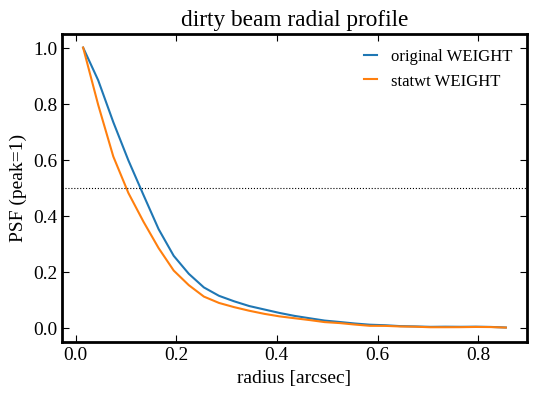

In [14]:
def radial_profile(img, rmax=30):
    cy, cx = np.unravel_index(np.argmax(img), img.shape)
    yy, xx = np.indices(img.shape)
    r = np.hypot(xx - cx, yy - cy)
    edges = np.arange(0, rmax, 1.0)
    prof = [np.mean(img[(r >= a) & (r < b)]) for a, b in zip(edges[:-1], edges[1:])]
    return 0.5 * (edges[:-1] + edges[1:]) * PIXEL_ARCSEC, np.array(prof)

fig, ax = plt.subplots(figsize=(6, 4))
for beam, label in [(raw_combined_beam, 'original WEIGHT'), (statwt_combined_beam, 'statwt WEIGHT')]:
    ax.plot(*radial_profile(beam[line_free_channel]), label=label)
ax.axhline(0.5, color='k', ls=':', lw=0.8)
ax.set(xlabel='radius [arcsec]', ylabel='PSF (peak=1)', title='dirty beam radial profile')
ax.legend()
plt.show()

PSFはΣw の配分　で形が決まる

### baselineごとのsigma scale factor

上の`sigma calibration factor`は観測全体をまとめた1つの数字なので、ここでは同じ量をbaselineごとに測り、`statwt`がbaselineごとのσを正しく推定しているかを見る。元WEIGHTのσ（= 1/√WEIGHT）に対する比として、次の2つを比較する。

1. **truth**：noisy−noiselessで取り出した真のnoiseのRMS / 元σ
2. **statwt**：`statwt`が書き込んだσ / 元σ

`statwt`はbaselineごとにline-free 8 channel × 2 correlation × 全積分（A: ν=11520、B: ν=1920 実数サンプル）から平均を引いた分散を推定するので、trueσに対して平均 −1/ν だけ小さめに出るはず（有限サンプルのバイアス）。

右の箱ひげ図はbaseline間のweightの広がり。全baselineのnoiseが同じσなら、有限サンプルだけで σ推定は相対 √(1/(2ν)) ばらつく（表の`expected_scatter_if_uniform_noise`）。truthのばらつきがこれと同じなら、simobserveのnoiseはbaseline間で一様で、statwtのweightの広がりは実際のnoise差ではなく推定誤差である。

偏り・ばらつきの期待値は`glint.uv_processing.statwt_finite_sample_expectation`から取る。実データ（G09）では真のnoiseが作れないので、`line_free_sample_counts`でbaselineごとのνを数え、statwt後のweightの広がりを√(2/ν)と比べることが同じ診断になる（statwtを`timebin`で分割した場合はνをbin数で割る）。

,observation,baselines,real_samples_per_baseline,median_truth_sigma_scale,median_statwt_sigma_scale,baseline_scatter_of_truth_scale,expected_scatter_if_uniform_noise,RMS(statwt/truth - 1),truth_baseline_weight_max/min,statwt_baseline_weight_max/min
0,A,903,11520,0.11232,0.11231,0.0066,0.0066,1.23e-04,1.091,1.091
1,B,903,1920,0.06528,0.06525,0.0160,0.0161,7.37e-04,1.274,1.277


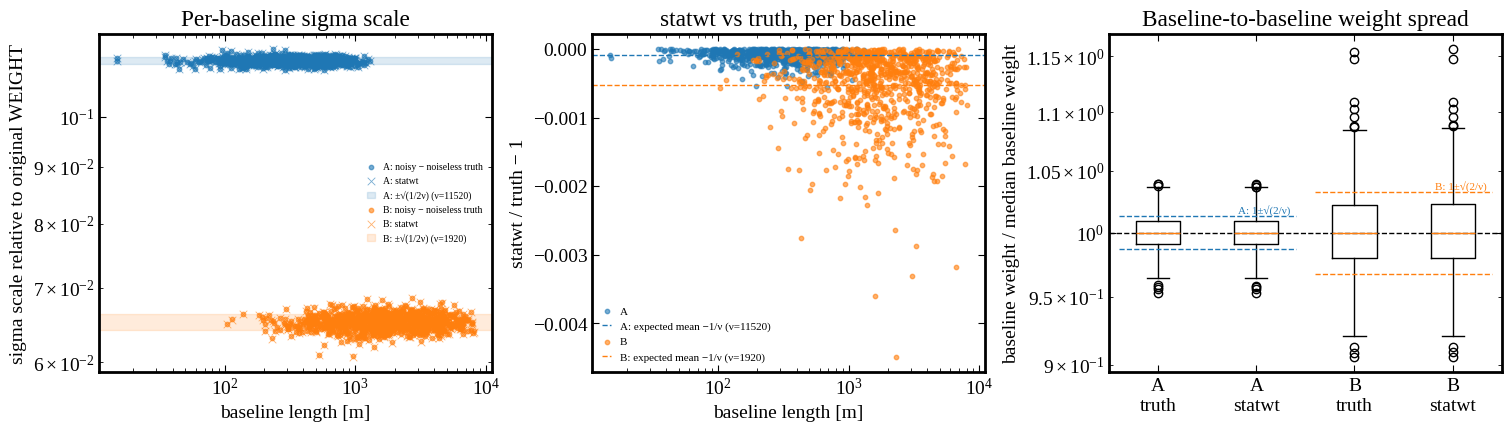

In [15]:
from glint.uv_processing import statwt_finite_sample_expectation

def baseline_sigma_scales_vs_truth(label, signal_ms, noisy_ms, statwt_ms):
    """baselineごとに、真のnoise（noisy−noiseless）とstatwtのσを、元WEIGHTのσに対する比で求める。"""
    signal = get_msdata(signal_ms, data_column='DATA', spw_id=0)
    noisy = get_msdata(noisy_ms, data_column='DATA', spw_id=0)
    statwt_data = get_msdata(statwt_ms, data_column='DATA', spw_id=0)
    noise = (noisy['data_pol'] - signal['data_pol'])[:, LINE_FREE, :]
    valid = ~(noisy['flag_pol'] | signal['flag_pol'])[:, LINE_FREE, :]
    sigma_original = 1.0 / np.sqrt(noisy['weight_pol'])        # (npol, nrow)
    sigma_statwt = 1.0 / np.sqrt(statwt_data['weight_pol'])
    baseline_length = np.hypot(noisy['uvw_m'][0], noisy['uvw_m'][1])
    baseline_id = noisy['antenna1'] * 1000 + noisy['antenna2']
    rows = []
    for key in np.unique(baseline_id):
        selected = baseline_id == key
        z = (noise[:, :, selected] / sigma_original[:, None, selected])[valid[:, :, selected]]
        if z.size < 2:
            continue
        rows.append({
            'observation': label,
            'antenna1': key // 1000, 'antenna2': key % 1000,
            'baseline_length_m': np.median(baseline_length[selected]),
            'real_samples': 2 * z.size,
            # 元WEIGHTのσに対する真のnoise RMSの比（上の sigma calibration factor のbaseline版）
            'truth_sigma_scale': np.sqrt(np.mean(np.abs(z)**2) / 2.0),
            # statwtが書いたσと元σの比
            'statwt_sigma_scale': np.median(sigma_statwt[:, selected] / sigma_original[:, selected]),
        })
    return pd.DataFrame(rows)

baseline_scale_table = pd.concat([
    baseline_sigma_scales_vs_truth('A', SIGNAL_MS, NOISY_MS, STATWT_A_MS),
    baseline_sigma_scales_vs_truth('B', SIGNAL_MS_B, NOISY_MS_B, STATWT_B_MS),
], ignore_index=True)
baseline_scale_table['statwt/truth - 1'] = (
    baseline_scale_table.statwt_sigma_scale / baseline_scale_table.truth_sigma_scale - 1.0
)

# 有限サンプルの期待値（偏り−1/ν、σばらつき√(1/2ν)、weightばらつき√(2/ν)）は
# glintの関数から取る。実データ（G09）でもline_free_sample_countsでνを数えて同じ関数を使う。
finite_sample = {}
baseline_summary_rows = []
for observation, group in baseline_scale_table.groupby('observation'):
    nu = group.real_samples.median()
    finite_sample[observation] = statwt_finite_sample_expectation(nu)
    truth_weight = 1.0 / group.truth_sigma_scale**2
    statwt_weight = 1.0 / group.statwt_sigma_scale**2
    baseline_summary_rows.append({
        'observation': observation,
        'baselines': len(group),
        'real_samples_per_baseline': int(nu),
        'median_truth_sigma_scale': group.truth_sigma_scale.median(),
        'median_statwt_sigma_scale': group.statwt_sigma_scale.median(),
        # 全baselineのnoiseが同じσなら、有限サンプルだけでσ推定は√(1/(2ν))相対でばらつく
        'baseline_scatter_of_truth_scale': group.truth_sigma_scale.std() / group.truth_sigma_scale.mean(),
        'expected_scatter_if_uniform_noise': float(finite_sample[observation]['sigma_scatter']),
        'RMS(statwt/truth - 1)': np.sqrt(np.mean(group['statwt/truth - 1']**2)),
        'truth_baseline_weight_max/min': truth_weight.max() / truth_weight.min(),
        'statwt_baseline_weight_max/min': statwt_weight.max() / statwt_weight.min(),
    })
baseline_summary_table = pd.DataFrame(baseline_summary_rows)
display(baseline_summary_table.style.format({
    'median_truth_sigma_scale': '{:.5f}',
    'median_statwt_sigma_scale': '{:.5f}',
    'baseline_scatter_of_truth_scale': '{:.4f}',
    'expected_scatter_if_uniform_noise': '{:.4f}',
    'RMS(statwt/truth - 1)': '{:.2e}',
    'truth_baseline_weight_max/min': '{:.3f}',
    'statwt_baseline_weight_max/min': '{:.3f}',
}))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for color, observation in zip(['C0', 'C1'], ['A', 'B']):
    group = baseline_scale_table.query('observation == @observation')
    expectation = finite_sample[observation]
    nu = int(group.real_samples.median())
    ax[0].scatter(group.baseline_length_m, group.truth_sigma_scale, s=10, color=color,
                  alpha=.6, label=f'{observation}: noisy − noiseless truth')
    ax[0].scatter(group.baseline_length_m, group.statwt_sigma_scale, s=30, color=color,
                  marker='x', lw=.6, alpha=.6, label=f'{observation}: statwt')
    # noiseが一様なら、σ推定はmedianの±√(1/2ν)（1σ）に散るはず
    median_scale = group.truth_sigma_scale.median()
    ax[0].axhspan(median_scale * (1 - expectation['sigma_scatter']),
                  median_scale * (1 + expectation['sigma_scatter']),
                  color=color, alpha=.15,
                  label=f'{observation}: ±√(1/2ν) (ν={nu})')
    ax[1].scatter(group.baseline_length_m, group['statwt/truth - 1'], s=10, color=color,
                  alpha=.6, label=observation)
    # 平均を引いた分散推定はσを 1/ν だけ小さめに出す
    ax[1].axhline(expectation['sigma_bias'], color=color, ls='--', lw=1,
                  label=f'{observation}: expected mean −1/ν (ν={nu})')
ax[0].set(xlabel='baseline length [m]', xscale='log', yscale='log',
          ylabel='sigma scale relative to original WEIGHT',
          title='Per-baseline sigma scale')
ax[0].legend(fontsize=7)
ax[1].set(xlabel='baseline length [m]', xscale='log',
          ylabel='statwt / truth − 1', title='statwt vs truth, per baseline')
ax[1].legend(fontsize=8)

box_values, box_labels = [], []
for observation in ['A', 'B']:
    group = baseline_scale_table.query('observation == @observation')
    for column, method in [('truth_sigma_scale', 'truth'), ('statwt_sigma_scale', 'statwt')]:
        weight = 1.0 / np.asarray(group[column])**2
        box_values.append(weight / np.median(weight))
        box_labels.append(f'{observation}\n{method}')
ax[2].boxplot(box_values, tick_labels=box_labels, showfliers=True)
ax[2].axhline(1.0, color='k', ls='--', lw=1)
# noiseが一様な場合のweightの期待ばらつき（1σ）: 1 ± √(2/ν)
for color, observation, x_low, x_high in [('C0', 'A', 0.6, 2.4), ('C1', 'B', 2.6, 4.4)]:
    spread = float(finite_sample[observation]['weight_scatter'])
    ax[2].hlines([1 - spread, 1 + spread], x_low, x_high,
                 color=color, ls='--', lw=1)
    ax[2].text(x_high - 0.05, 1 + spread, f'{observation}: 1±√(2/ν)',
               color=color, fontsize=8, ha='right', va='bottom')
ax[2].set(yscale='log', ylabel='baseline weight / median baseline weight',
          title='Baseline-to-baseline weight spread')
plt.show()

基線長ごとのfactorの違いはほぼない
Bの方が積分時間長いのにばらつきが大きいのは、baselineあたりのvisibilityが6倍少ないから（A: 3600s/10s=360, B: 1800s/30s=60）
真ん中で、-1/ν より小さい点があるのは、二乗して自由度2のχ^2分布になっているから（Gauss分布に比べて裾が広い）

### 結論

1. **一致する。** FINUFFT type-2はsimobserve signalを相対RMS 1.4×10⁻³で再現（PBなしで1.2×10⁻³なので大半はPB近似以外の演算子誤差）。type-1逆NUFFTのdirty imageもtcleanと相対RMS 1.2×10⁻³・相関0.999999・peak位置一致。
2. **12 mならvisibility 2%まで圧縮でき、精度悪化も無視できる。** 代表uv点でのモデル評価の誤差はthermal σの2.6×10⁻⁴倍（48 mまで振っても小さい）。
3. **Gaussianだが絶対スケールは要較正。** 実部と虚部は同じσで表せるGaussianになっている。CASAの`WEIGHT`は相対値としては正しいが絶対スケールが大きくずれる（sigma calibration factor 0.11）。
4. simobserve の元の WEIGHT は、異なるintegration time/configurationで生成したthermal noiseの相対varianceを反映しておらず、そのままconcatするとuv weightとPSFが誤る。一方、line-free channelに対する statwt は真のnoise varianceをほぼ完全に復元した。statwt を正しく行うと、分解能が改善するだけでなく、RMSも6%改善した。基線ごとの重みの統計的な差も見られない。